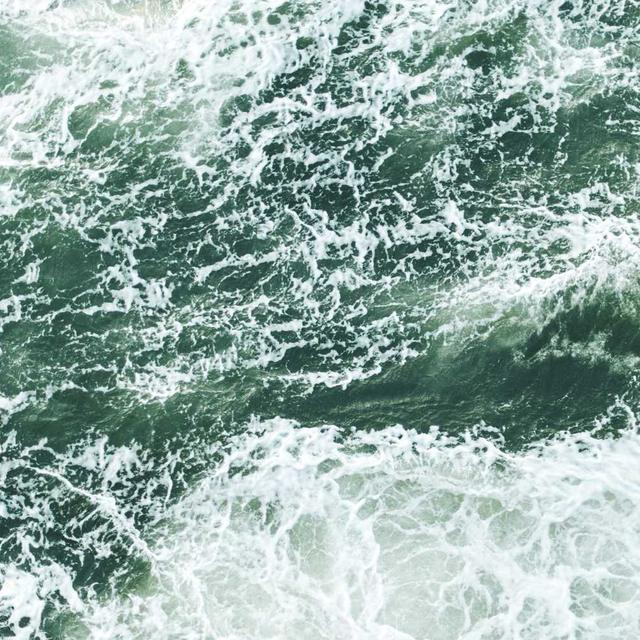

In [2]:
# Setup Cell — Load image

import requests
import numpy as np
from PIL import Image
from io import BytesIO

url = "https://picsum.photos/640"

response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")

img

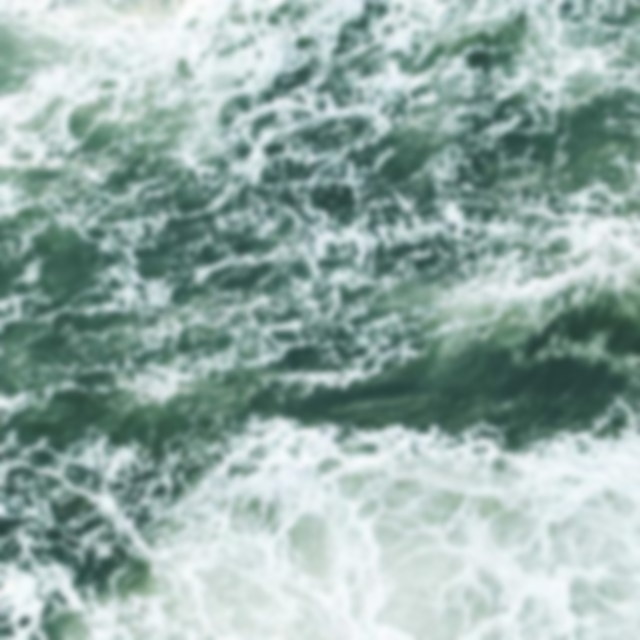

In [3]:
# Cell 1 — Blur
from PIL import ImageFilter
blurred = img.filter(ImageFilter.GaussianBlur(radius=3))
blurred

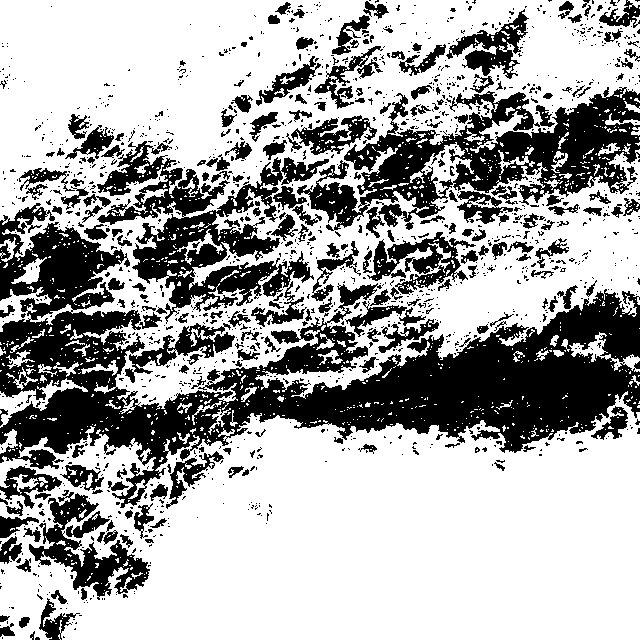

In [4]:
# Cell 2 — Thresholding (separate light from dark)
gray_array = np.array(img.convert("L"))
threshold = 128
binary = (gray_array > threshold).astype(np.uint8) * 255
Image.fromarray(binary)

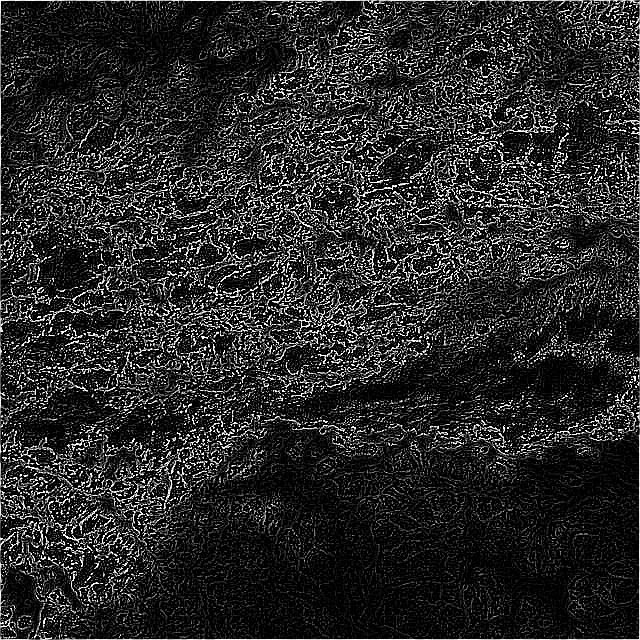

In [5]:
# Cell 3 — Edge detection (simple gradient)
from PIL import ImageFilter
edges = img.convert("L").filter(ImageFilter.FIND_EDGES)
edges

In [6]:
# Cell 4 — Frame sampling concept
frame_count = 0
sample_rate = 5  # process every 5th frame

for i in range(20):
    if i % sample_rate == 0:
        print(f"Frame {i}: PROCESS")
    else:
        print(f"Frame {i}: skip")

Frame 0: PROCESS
Frame 1: skip
Frame 2: skip
Frame 3: skip
Frame 4: skip
Frame 5: PROCESS
Frame 6: skip
Frame 7: skip
Frame 8: skip
Frame 9: skip
Frame 10: PROCESS
Frame 11: skip
Frame 12: skip
Frame 13: skip
Frame 14: skip
Frame 15: PROCESS
Frame 16: skip
Frame 17: skip
Frame 18: skip
Frame 19: skip


In [7]:
# Cell 5 — Low light policy notes
policy = {
    "step1": "Convert to grayscale to reduce noise",
    "step2": "Apply GaussianBlur with radius=2 to smooth grain",
    "step3": "Increase contrast using histogram equalization",
    "step4": "Use threshold=80 instead of 128 for dark images",
    "step5": "Sample every 3rd frame only to reduce compute"
}
for k, v in policy.items():
    print(f"{k}: {v}")

step1: Convert to grayscale to reduce noise
step2: Apply GaussianBlur with radius=2 to smooth grain
step3: Increase contrast using histogram equalization
step4: Use threshold=80 instead of 128 for dark images
step5: Sample every 3rd frame only to reduce compute
